# 14.01 — Topic Extraction Dataset Audit & Validation

This notebook serves as empirical research evidence for the Topic Extractor dataset construction.
It inspects, validates, and visualizes:
1. **Canonical Skill Ontology** (111 academic skills)
2. **GSM8K Raw Natural Language Audit** (8,792 questions evaluated for explicit skill mapping)
3. **Ontology Seed Dataset** (high-confidence template queries)
4. **Student-Style Dataset** (realistic student utterances and problem requests)
5. **Combined Final Dataset** (deduplicated, conflict-free training corpus)


In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline


## 1. Load Pre-Generated Artifacts
*Note: This notebook only reads existing dataset artifacts; it does not modify any source data.*

In [2]:
PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()

# File paths
ONTOLOGY_PATH = PROJECT_ROOT / 'data' / 'processed' / 'canonical_skill_ontology.json'
GSM8K_AUDIT_PATH = PROJECT_ROOT / 'data' / 'topic_extraction' / 'processed' / 'gsm8k_audit.csv'
SEED_DATASET_PATH = PROJECT_ROOT / 'data' / 'topic_extraction' / 'processed' / 'ontology_seed_dataset.csv'
STUDENT_DATASET_PATH = PROJECT_ROOT / 'data' / 'topic_extraction' / 'processed' / 'student_style_dataset.csv'
COMBINED_DATASET_PATH = PROJECT_ROOT / 'data' / 'topic_extraction' / 'processed' / 'topic_extraction_dataset.csv'

# Load artifacts
with open(ONTOLOGY_PATH, 'r', encoding='utf-8') as f:
    ontology = json.load(f)

df_gsm8k = pd.read_csv(GSM8K_AUDIT_PATH)
df_seed = pd.read_csv(SEED_DATASET_PATH)
df_student = pd.read_csv(STUDENT_DATASET_PATH)
df_combined = pd.read_csv(COMBINED_DATASET_PATH)

print('All 5 dataset artifacts loaded successfully.')


All 5 dataset artifacts loaded successfully.


## 2. Core Dataset Metrics & Audit Summary

In [3]:
# Compute validation metrics
canonical_skills_count = len(ontology)

gsm8k_total = len(df_gsm8k)
gsm8k_confident = int((df_gsm8k['match_type'] == 'SINGLE_MATCH').sum())
gsm8k_ambiguous = int((df_gsm8k['match_type'] == 'MULTI_MATCH').sum())
gsm8k_unmatched = int((df_gsm8k['match_type'] == 'NO_MATCH').sum())
gsm8k_skills_covered = df_gsm8k.loc[df_gsm8k['match_type'] == 'SINGLE_MATCH', 'matched_skill_code'].nunique()

seed_examples = len(df_seed)
student_examples = len(df_student)
combined_examples = len(df_combined)

final_skills_covered = df_combined['canonical_name'].nunique()
per_skill = df_combined.groupby('canonical_name').size()
min_per_skill = int(per_skill.min())
max_per_skill = int(per_skill.max())

# Deduplication check
normalized_texts = df_combined['text'].astype(str).str.strip().str.lower()
duplicate_normalized = int(normalized_texts.duplicated().sum())

# Label conflict check
text_to_skills = df_combined.groupby(normalized_texts)['skill_id'].nunique()
conflicting_labels = int((text_to_skills > 1).sum())

summary_df = pd.DataFrame([
    {'Metric': 'Canonical Skills in Ontology', 'Value': canonical_skills_count, 'Target / Status': '111 skills'},
    {'Metric': 'GSM8K Total Questions', 'Value': gsm8k_total, 'Target / Status': '8,792 rows'},
    {'Metric': 'Confident GSM8K Matches', 'Value': gsm8k_confident, 'Target / Status': '11 confident'},
    {'Metric': 'GSM8K Skills Covered', 'Value': f'{gsm8k_skills_covered} / 111', 'Target / Status': 'Low direct overlap (7/111)'},
    {'Metric': 'Ontology Seed Examples', 'Value': seed_examples, 'Target / Status': '2,466 examples'},
    {'Metric': 'Student-Style Examples', 'Value': student_examples, 'Target / Status': '1,997 examples'},
    {'Metric': 'Combined Dataset Examples', 'Value': combined_examples, 'Target / Status': '4,463 examples'},
    {'Metric': 'Final Skill Coverage', 'Value': f'{final_skills_covered} / 111', 'Target / Status': '100% Coverage (111/111)'},
    {'Metric': 'Minimum Examples per Skill', 'Value': min_per_skill, 'Target / Status': '>= 30 per skill'},
    {'Metric': 'Maximum Examples per Skill', 'Value': max_per_skill, 'Target / Status': '<= 125 per skill'},
    {'Metric': 'Duplicate Normalized Texts', 'Value': duplicate_normalized, 'Target / Status': '0 duplicates (Passed)'},
    {'Metric': 'Conflicting Multi-Labels', 'Value': conflicting_labels, 'Target / Status': '0 conflicts (Passed)'},
])

summary_df


,Metric,Value,Target / Status
0,Canonical Skills in Ontology,111,111 skills
1,GSM8K Total Questions,8792,"8,792 rows"
2,Confident GSM8K Matches,11,11 confident
3,GSM8K Skills Covered,7 / 111,Low direct overlap (7/111)
4,Ontology Seed Examples,2466,"2,466 examples"
5,Student-Style Examples,1997,"1,997 examples"
6,Combined Dataset Examples,4463,"4,463 examples"
7,Final Skill Coverage,111 / 111,100% Coverage (111/111)
8,Minimum Examples per Skill,33,>= 30 per skill
9,Maximum Examples per Skill,123,<= 125 per skill


## 3. Academic Domain & Category Distribution

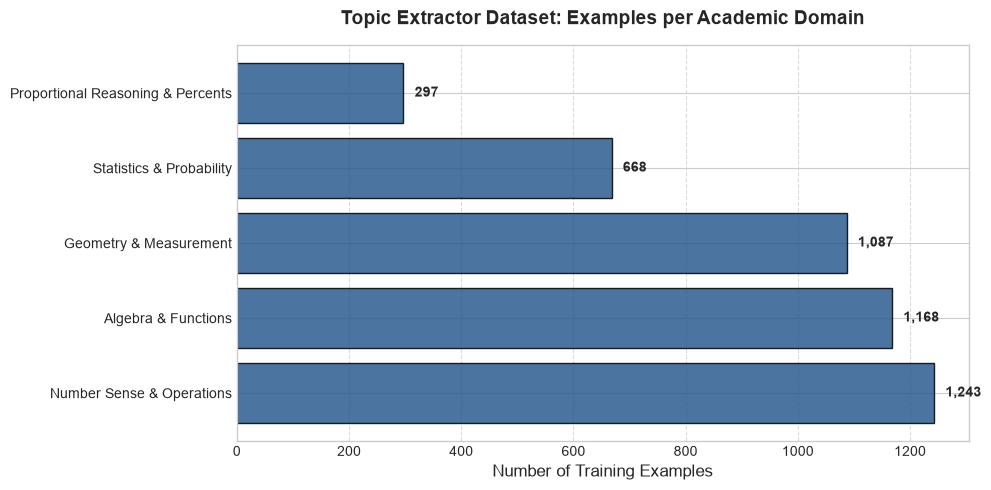

,category,total_examples,unique_skills
2,Number Sense & Operations,1243,31
0,Algebra & Functions,1168,26
1,Geometry & Measurement,1087,29
4,Statistics & Probability,668,16
3,Proportional Reasoning & Percents,297,9


In [4]:
category_dist = df_combined.groupby('category').agg(
    total_examples=('text', 'count'),
    unique_skills=('canonical_name', 'nunique')
).reset_index().sort_values('total_examples', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(category_dist['category'], category_dist['total_examples'], color='#2b5c8f', edgecolor='black', alpha=0.85)
ax.set_xlabel('Number of Training Examples', fontsize=12)
ax.set_title('Topic Extractor Dataset: Examples per Academic Domain', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 20, bar.get_y() + bar.get_height()/2, f'{int(w):,}', va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

category_dist


## 4. Dataset Composition by Source

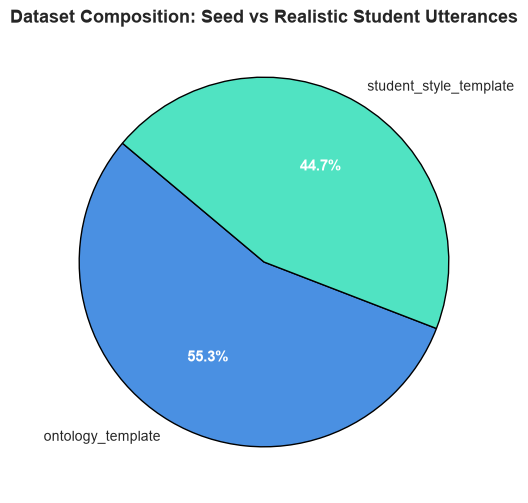

,Source,Count,Percentage
0,ontology_template,2466,55.25%
1,student_style_template,1997,44.75%


In [5]:
source_counts = df_combined['source'].value_counts().reset_index()
source_counts.columns = ['Source', 'Count']
source_counts['Percentage'] = (source_counts['Count'] / len(df_combined) * 100).round(2).astype(str) + '%'

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    source_counts['Count'],
    labels=source_counts['Source'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#4a90e2', '#50e3c2'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
plt.setp(autotexts, size=11, weight='bold', color='white')
ax.set_title('Dataset Composition: Seed vs Realistic Student Utterances', fontsize=13, fontweight='bold')
plt.show()

source_counts


## 5. Examples per Skill Balance

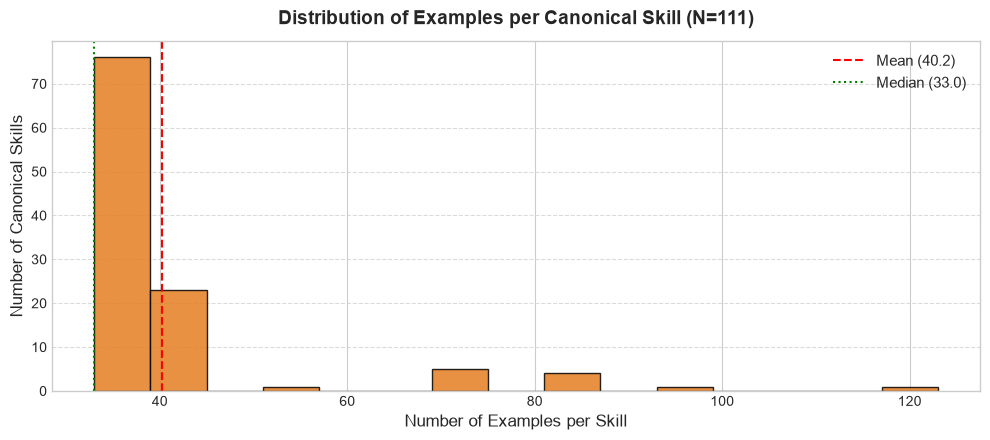

,Examples per Skill Statistics
count,111.000000
mean,40.207207
std,15.560508
min,33.000000
25%,33.000000
50%,33.000000
75%,43.000000
max,123.000000


In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(per_skill, bins=15, color='#e67e22', edgecolor='black', alpha=0.85)
ax.set_xlabel('Number of Examples per Skill', fontsize=12)
ax.set_ylabel('Number of Canonical Skills', fontsize=12)
ax.set_title('Distribution of Examples per Canonical Skill (N=111)', fontsize=14, fontweight='bold', pad=12)
ax.axvline(per_skill.mean(), color='red', linestyle='dashed', linewidth=1.5, label=f'Mean ({per_skill.mean():.1f})')
ax.axvline(per_skill.median(), color='green', linestyle='dotted', linewidth=1.5, label=f'Median ({per_skill.median():.1f})')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

per_skill.describe().to_frame(name='Examples per Skill Statistics')


## 6. Sample Utterances with Labels

In [7]:
sample_df = df_combined.sample(10, random_state=42)[
    ['text', 'skill_name', 'category', 'template_group', 'source']
]
sample_df


,text,skill_name,category,template_group,source
297,How does Interior Angles Triangle work in math?,Interior Angles Triangle,Geometry & Measurement,concept_question,ontology_template
969,Teach me about Scientific Notation,Scientific Notation,Number Sense & Operations,learning_request,ontology_template
2037,I don't understand Slope From Situation,Finding Slope From Situation,Algebra & Functions,misunderstanding_statement,ontology_template
598,Show me how Ordering Positive Decimals works,Ordering Positive Decimals,Number Sense & Operations,instruction_request,ontology_template
2821,How do I find the probability of the complemen...,Probability of a Single Event,Statistics & Probability,complement,student_style_template
2171,Can we review Slope From Ordered Pairs together?,Finding Slope from Ordered Pairs,Algebra & Functions,review_request,ontology_template
4261,How do I solve problems involving Slope From O...,Finding Slope from Ordered Pairs,Algebra & Functions,alias_query,student_style_template
1904,Help me understand Greatest Common Divisor,Greatest Common Factor,Number Sense & Operations,help_request,ontology_template
1216,I am having trouble with Solving Linear Equations,Linear Equations,Algebra & Functions,struggle_statement,ontology_template
677,Can we review Rounding together?,Rounding,Number Sense & Operations,review_request,ontology_template
